# Spaceship-Titanic


In [125]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn

## Preparing datasets

In [126]:
data_train = pd.read_csv('data/train.csv')
data_test = pd.read_csv('data/test.csv')

data_train["train_test"] = True
data_test["train_test"] = False
data_test["Transported"] = np.nan

data_merged = pd.concat([data_train, data_test], axis=0, ignore_index=True)

In [127]:
print(data_train.columns)

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported', 'train_test'],
      dtype='object')


In [128]:
print(data_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
 14  train_test    8693 non-null   bool   
dtypes: bool(2), float64(6), object(7)
memory usage: 900.0+ KB
None


In [129]:
print("Null values per column in train: \n", data_train.isnull().sum())

Null values per column in train: 
 PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
train_test        0
dtype: int64


In [130]:
print(data_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
 13  train_test    4277 non-null   bool   
 14  Transported   0 non-null      float64
dtypes: bool(1), float64(7), object(7)
memory usage: 472.1+ KB
None


In [131]:
print("Null values per column in test: \n", data_test.isnull().sum())

Null values per column in test: 
 PassengerId        0
HomePlanet        87
CryoSleep         93
Cabin            100
Destination       92
Age               91
VIP               93
RoomService       82
FoodCourt        106
ShoppingMall      98
Spa              101
VRDeck            80
Name              94
train_test         0
Transported     4277
dtype: int64


### Preprocessing & Feature Engineering
- most values exist, only < 2.5% are missing. Imputing with Mode or Mean seems reasonable

In [132]:
# splitting PassengerId into Group and GroupSize, unsure if this is useful
data_merged[['groupId', 'groupSize']] = data_merged['PassengerId'].str.split('_', expand=True)

# splitting Cabin into three columns to see whether parts of the ship were more likely to survive
data_merged[['cabin_deck', 'cabin_num', 'cabin_side']] = data_merged['Cabin'].str.split('/', expand=True)

# filling in the missing values
column_mode = ['cabin_deck', 'cabin_num', 'cabin_side', 'Destination', 'HomePlanet', 'CryoSleep', 'VIP']
for col in column_mode:
    data_merged.fillna({col : data_merged[col].mode()[0]}, inplace=True)

data_merged.fillna({'Age': data_merged['Age'].mean()}, inplace=True)

# bin the Age column into 8 groups
bins = list(range(0, 81, 10))
labels_age = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80']
data_merged['Age_bins'] = pd.cut(data_merged['Age'], bins=bins, labels=labels_age, include_lowest=True)

# assuming no spending means no service used
column_spending = ['RoomService','FoodCourt','Spa','ShoppingMall','VRDeck']
for col in column_spending:
    data_merged.fillna({col : 0.0}, inplace=True)

# group into Spending column to simplify the data
data_merged['Spending'] = data_merged['RoomService'] + data_merged['FoodCourt'] + data_merged['Spa'] + data_merged['ShoppingMall'] + data_merged['VRDeck']

# bin the Spending column into 5 groups
bins = [0,100, 2000, 5000, 10000, 40000]
labels_spending = ['0-100', '100-2000', '2000-5000', '5000-10000', '10000-40000']
data_merged['Spending_bins'] = pd.cut(data_merged['Spending'], bins=bins, labels=labels_spending, include_lowest=True)

# Name seemed too unique to be useful
column_drop = ['PassengerId', 'Name', 'Cabin', 'Age', 'Spending','cabin_num', 'RoomService', 'FoodCourt', 'Spa', 'ShoppingMall', 'VRDeck']
drop_merged_redcued = data_merged.drop(column_drop, axis=1)

# one-hot encoding 
data_merged_dummies = pd.get_dummies(drop_merged_redcued, columns=['HomePlanet', 'Destination', 'cabin_deck', 'cabin_side', 'Spending_bins', 'Age_bins'])


/tmp/ipykernel_31428/1101034411.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_merged.fillna({col : data_merged[col].mode()[0]}, inplace=True)


#### Dataset for exploratory analysis

In [133]:
data_train_explore = data_merged[data_merged['train_test'] == True]
print("Xtrain shape: ", data_train_explore.shape)
data_train_explore.info()

Xtrain shape:  (8693, 23)
<class 'pandas.core.frame.DataFrame'>
Index: 8693 entries, 0 to 8692
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   PassengerId    8693 non-null   object  
 1   HomePlanet     8693 non-null   object  
 2   CryoSleep      8693 non-null   bool    
 3   Cabin          8494 non-null   object  
 4   Destination    8693 non-null   object  
 5   Age            8693 non-null   float64 
 6   VIP            8693 non-null   bool    
 7   RoomService    8693 non-null   float64 
 8   FoodCourt      8693 non-null   float64 
 9   ShoppingMall   8693 non-null   float64 
 10  Spa            8693 non-null   float64 
 11  VRDeck         8693 non-null   float64 
 12  Name           8493 non-null   object  
 13  Transported    8693 non-null   object  
 14  train_test     8693 non-null   bool    
 15  groupId        8693 non-null   object  
 16  groupSize      8693 non-null   object  
 17  cabin_deck  

#### Dataset for training

In [134]:
data_xtrain_dummies = data_merged_dummies[data_merged_dummies['train_test'] == True].drop(['Transported', 'train_test'], axis=1)
data_ytrain_dummies = data_merged_dummies[data_merged_dummies['train_test'] == True]['Transported']

data_xtest_dummies = data_merged_dummies[data_merged_dummies['train_test'] == False].drop(['Transported', 'train_test'], axis=1)

print("Xtrain shape: ", data_xtrain_dummies.shape)
print("Ytrain shape: ", data_ytrain_dummies.shape)

print("Xtest shape:  ", data_xtest_dummies.shape)

Xtrain shape:  (8693, 33)
Ytrain shape:  (8693,)
Xtest shape:   (4277, 33)


### Exploratory analysis

In [135]:
column_target = ['Transported']
column_relevant = ['HomePlanet', 'CryoSleep','Destination', 'VIP', 'cabin_deck', 'cabin_side', 'Spending_bins', 'Age_bins', 'groupSize']
column_categorical = ['HomePlanet', 'Destination', 'cabin_deck', 'cabin_side', 'Spending_bins', 'Age_bins', 'groupSize']
column_numerical = ['CryoSleep', 'VIP']
columns_combined = column_categorical + column_numerical

xaxis_orders = [
    ['Earth', 'Europa', 'Mars'],  # HomePlanet
    ['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e'],  # Destination
    ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'],  # cabin_deck
    ['P', 'S'],  # cabin_side
    ['0-100', '100-2000', '2000-5000', '5000-10000', '10000-40000'],  # Spending_bins
    ['10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80'],  # Age_bins
    ['01', '02', '03', '04', '05', '06', '07', '08'],  # groupSize
    [False, True],  # CryoSleep
    [False, True]   # VIP
]


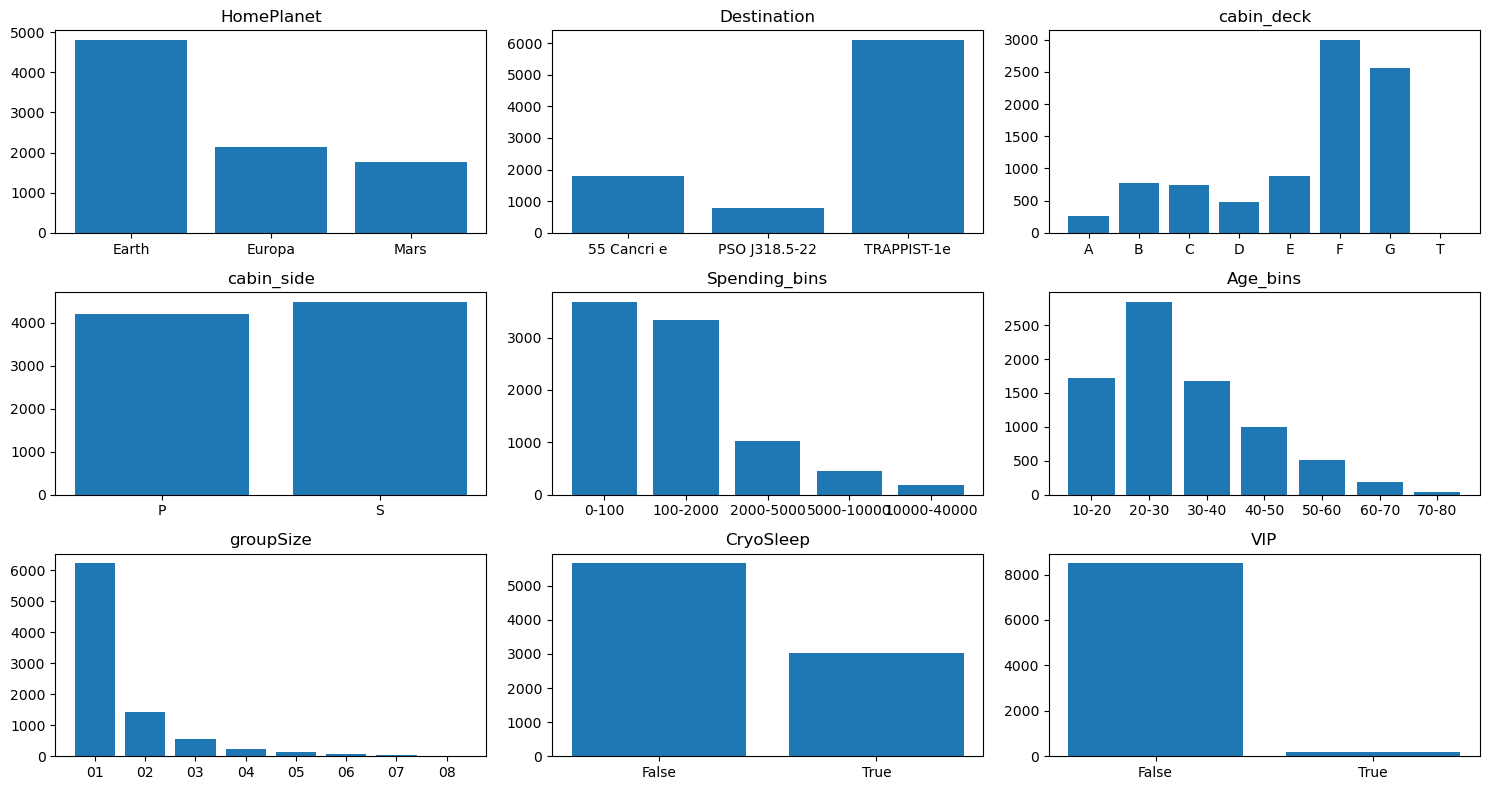

In [136]:
fig, ax = plt.subplots(3, 3, figsize=(15, 8))
ax = ax.flatten()

for idx, col in enumerate(columns_combined):
    bottom = np.zeros(len(xaxis_orders[idx]))
    transport_counts = data_train_explore[col].value_counts()
    transport_counts = transport_counts.reindex(xaxis_orders[idx])



    ax[idx].bar(transport_counts.index, transport_counts.values)

    ax[idx].set_xticks(np.arange(len(xaxis_orders[idx])), labels=xaxis_orders[idx])
    ax[idx].set_title(col)

plt.tight_layout()
plt.show()

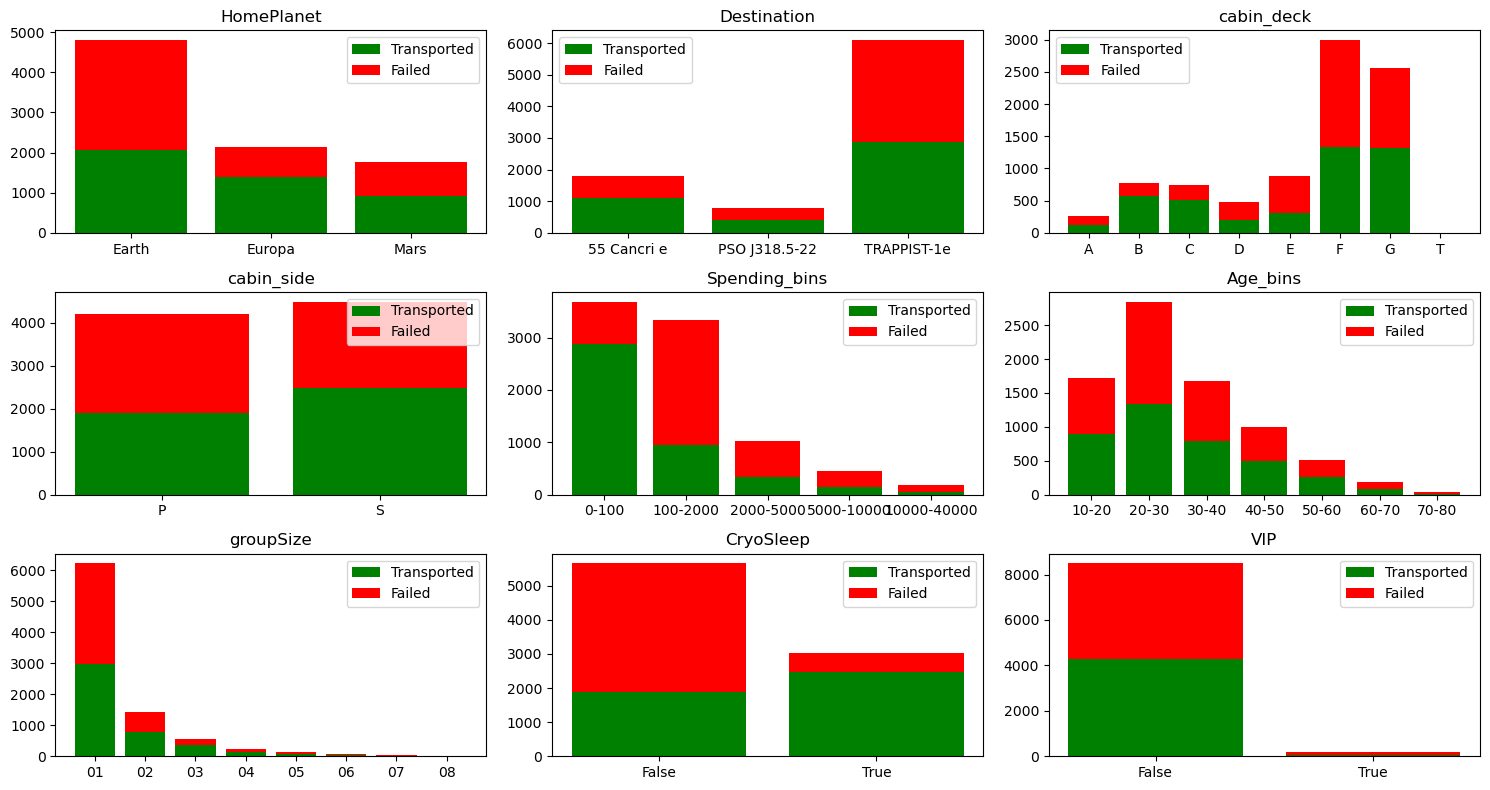

In [137]:
fig, ax = plt.subplots(3, 3, figsize=(15, 8))
ax = ax.flatten()


for idx, col in enumerate(columns_combined):
    bottom = np.zeros(len(xaxis_orders[idx]))
    transport_counts = data_train_explore[data_train_explore['Transported'] == True][col].value_counts()
    transport_counts = transport_counts.reindex(xaxis_orders[idx])

    fail_counts = data_train_explore[data_train_explore['Transported'] == False][col].value_counts()
    fail_counts = fail_counts.reindex(xaxis_orders[idx])


    ax[idx].bar(transport_counts.index, transport_counts.values, label='Transported', color='green', bottom=bottom)
    bottom += transport_counts.values
    ax[idx].bar(fail_counts.index, fail_counts.values, label='Failed', color='red', bottom=bottom)

    ax[idx].set_xticks(np.arange(len(xaxis_orders[idx])))
    ax[idx].set_xticklabels(xaxis_orders[idx])
    ax[idx].legend()
    ax[idx].set_title(col)

plt.tight_layout()
plt.show()

In [138]:
for c in columns_combined:
    print('Survival Correlation by:', c)
    print(data_train_explore[[c, "Transported"]].groupby(c, as_index=False, observed=False).mean())
    print('-'*10, '\n')


Survival Correlation by: HomePlanet
  HomePlanet Transported
0      Earth    0.427649
1     Europa    0.658846
2       Mars    0.523024
---------- 

Survival Correlation by: Destination
     Destination Transported
0    55 Cancri e        0.61
1  PSO J318.5-22    0.503769
2    TRAPPIST-1e    0.472199
---------- 

Survival Correlation by: cabin_deck
  cabin_deck Transported
0          A    0.496094
1          B    0.734275
2          C    0.680054
3          D    0.433054
4          E    0.357306
5          F    0.444036
6          G    0.516217
7          T         0.2
---------- 

Survival Correlation by: cabin_side
  cabin_side Transported
0          P     0.45126
1          S    0.552708
---------- 

Survival Correlation by: Spending_bins
  Spending_bins Transported
0         0-100     0.78209
1      100-2000    0.284901
2     2000-5000    0.329138
3    5000-10000    0.328947
4   10000-40000    0.303867
---------- 

Survival Correlation by: Age_bins
  Age_bins Transported
0     0-10

- users in CryoSleep had the highest chance of survival
- certain cabin_levels seem to be safer, e.g. B,C
- the majority of the lowest spending_bin survived 

**Open Question:**
- are VIPs in CryoSleep more often? **No, actually less often**
- are the safe cabin_levels populated by VIPs? **No, VIPs are spread across most decks, but percentage wise there are more in the safe decks**
- are VIPs the biggest spenders?
- are big spenders on special decks?

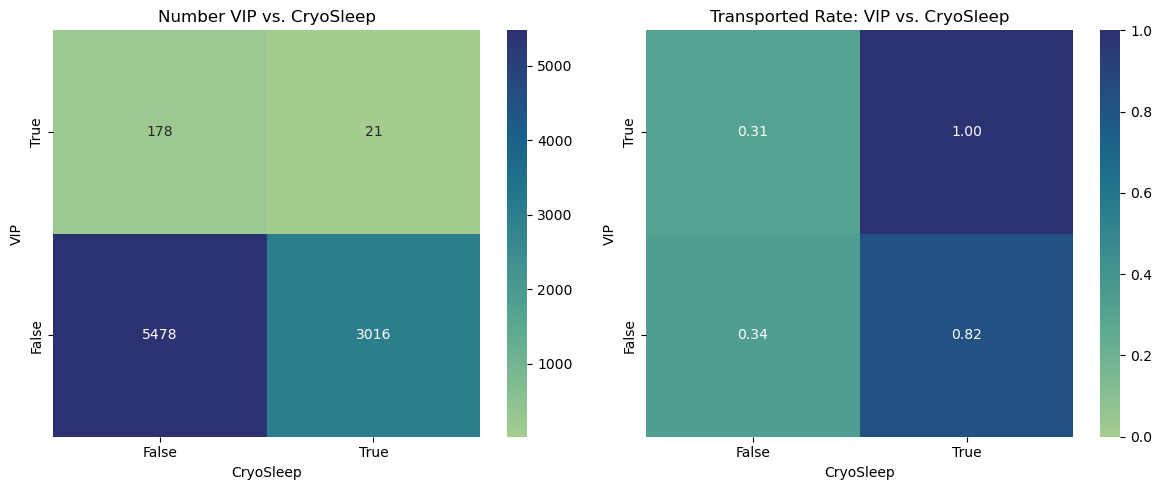

In [150]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = ax.flatten()

cross_vip_deck = pd.crosstab(data_train_explore['VIP'], data_train_explore['CryoSleep']).reindex(index=[True,False])
sns.heatmap(cross_vip_deck, annot=True, fmt='d', ax=ax[0], cmap="crest")
ax[0].set_title('Number VIP vs. CryoSleep')
ax[0].set_ylabel('VIP')
ax[0].set_xlabel('CryoSleep')

pivot_vip_deck = data_train_explore.groupby(['VIP', 'CryoSleep'])['Transported'].mean().unstack().reindex(index=[True,False]).astype(float)
sns.heatmap(pivot_vip_deck, annot=True, fmt=".2f", ax=ax[1], cmap="crest", vmin=0, vmax=1)
ax[1].set_title('Transported Rate: VIP vs. CryoSleep')
ax[1].set_ylabel('VIP')
ax[1].set_xlabel('CryoSleep')

plt.tight_layout()
plt.show()

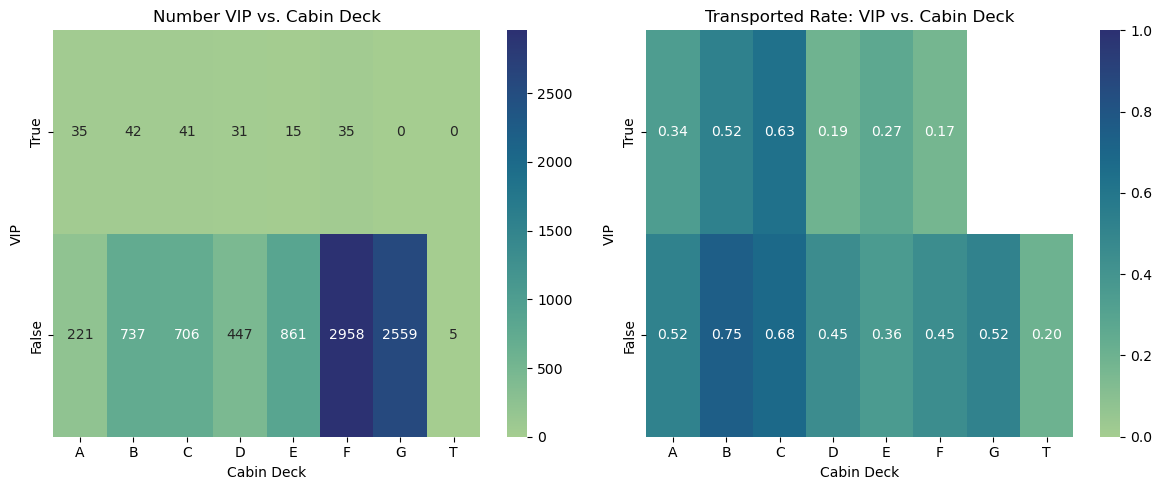

In [149]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = ax.flatten()

cross_vip_deck = pd.crosstab(data_train_explore['VIP'], data_train_explore['cabin_deck']).reindex(index=[True,False])
sns.heatmap(cross_vip_deck, annot=True, fmt='d', ax=ax[0], cmap="crest")
ax[0].set_title('Number VIP vs. Cabin Deck')
ax[0].set_ylabel('VIP')
ax[0].set_xlabel('Cabin Deck')

pivot_vip_deck = data_train_explore.groupby(['VIP', 'cabin_deck'])['Transported'].mean().unstack().reindex(index=[True,False]).astype(float)
sns.heatmap(pivot_vip_deck, annot=True, fmt=".2f", ax=ax[1], cmap="crest", vmin=0, vmax=1)
ax[1].set_title('Transported Rate: VIP vs. Cabin Deck')
ax[1].set_ylabel('VIP')
ax[1].set_xlabel('Cabin Deck')

plt.tight_layout()
plt.show()